# Problem 1:

Part 1:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = 20
x_min, x_max = 0.0, 5.0
sigma = 0.3
seed = 301
rng = np.random.default_rng(seed)

In [2]:
def f(x):
    return x + np.sin(1.5 * x)

In [3]:
x = rng.uniform(x_min, x_max, size=n)
eps = rng.normal(loc=0.0, scale=sigma, size=n)
y = f(x) + eps

print('x shape:', x.shape, ' y shape:', y.shape)
print('x range:', (x.min(), x.max()))

x shape: (20,)  y shape: (20,)
x range: (0.07013050715300617, 4.937112547283359)


In [4]:
x_line = np.linspace(x_min, x_max, 400)
f_line = f(x_line)

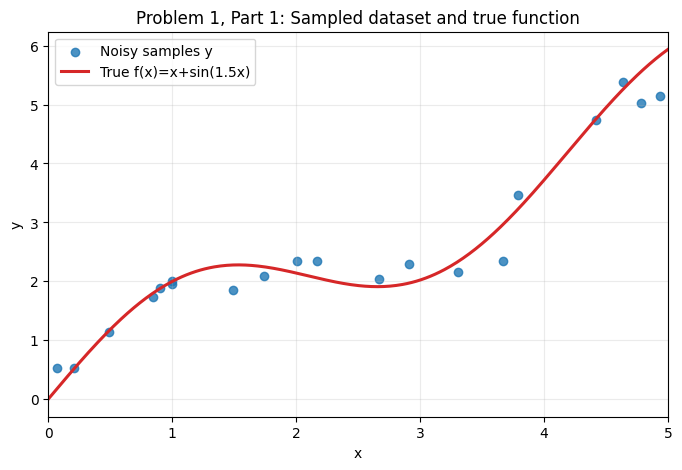

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='tab:blue', alpha=0.8, label='Noisy samples y')
plt.plot(x_line, f_line, color='tab:red', linewidth=2.2, label='True f(x)=x+sin(1.5x)')
plt.xlim(x_min, x_max)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Problem 1, Part 1: Sampled dataset and true function')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

 Part 2:

In [6]:
degrees = [1, 3, 5, 10]

def g_predict(x_in, coeffs):
    return np.polyval(coeffs, x_in)

coeffs_by_degree = {d: np.polyfit(x, y, d) for d in degrees}
yhat_train_by_degree = {d: g_predict(x, coeffs_by_degree[d]) for d in degrees}
yhat_line_by_degree = {d: g_predict(x_line, coeffs_by_degree[d]) for d in degrees}
mse_by_degree = {d: np.mean((y - yhat_train_by_degree[d]) ** 2) for d in degrees}

for d in degrees:
    print(f'g{d} train MSE: {mse_by_degree[d]:.6f}')

g1 train MSE: 0.351018
g3 train MSE: 0.102375
g5 train MSE: 0.047843
g10 train MSE: 0.026780


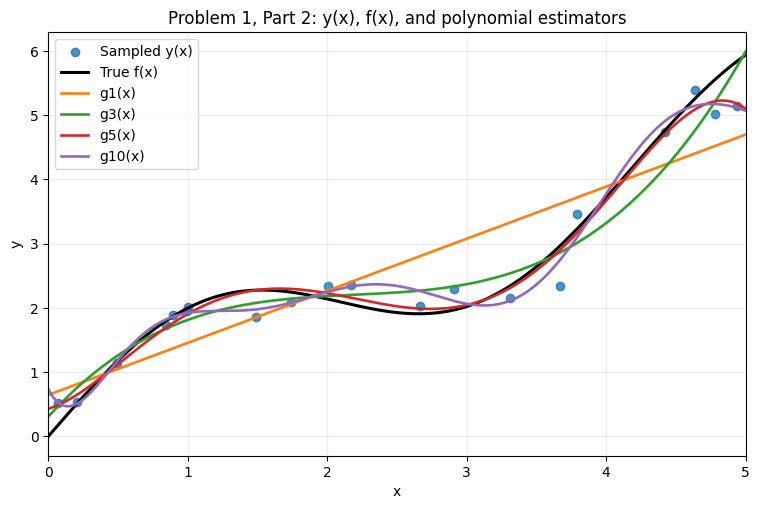

In [7]:
plt.figure(figsize=(9, 5.5))
plt.scatter(x, y, color='tab:blue', alpha=0.8, label='Sampled y(x)')
plt.plot(x_line, f_line, color='black', linewidth=2.2, label='True f(x)')

colors = {1: 'tab:orange', 3: 'tab:green', 5: 'tab:red', 10: 'tab:purple'}
for d in degrees:
    plt.plot(x_line, yhat_line_by_degree[d], color=colors[d], linewidth=1.9, label=f'g{d}(x)')

plt.xlim(x_min, x_max)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Problem 1, Part 2: y(x), f(x), and polynomial estimators')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

From the combined plot and training MSE values, **g1** is the underfitting estimator (too rigid/high bias), while **g10** is the overfitting estimator (excessive wiggle/high variance on sparse noisy data).

# Part 3:

In [8]:
n_datasets = 100
train_size = 50
test_size = 200
degree_grid = np.arange(1, 16)

seed_part3 = 302
rng_p3 = np.random.default_rng(seed_part3)

# Fixed x across all 100 training datasets
x_train_base = np.sort(rng_p3.uniform(x_min, x_max, size=train_size))
X_train_sets = np.repeat(x_train_base[None, :], n_datasets, axis=0)

# 100 noisy training datasets sampled from y(x)=f(x)+N(0,sigma^2)
f_train_base = f(x_train_base)
train_noise = rng_p3.normal(loc=0.0, scale=sigma, size=(n_datasets, train_size))
Y_train_sets = f_train_base[None, :] + train_noise

# Fixed test set shared by all fitted models
x_test = np.sort(rng_p3.uniform(x_min, x_max, size=test_size))
f_test = f(x_test)
test_noise = rng_p3.normal(loc=0.0, scale=sigma, size=test_size)
y_test = f_test + test_noise

print('X_train_sets shape:', X_train_sets.shape, 'Y_train_sets shape:', Y_train_sets.shape)
print('x_test shape:', x_test.shape, 'y_test shape:', y_test.shape)

X_train_sets shape: (100, 50) Y_train_sets shape: (100, 50)
x_test shape: (200,) y_test shape: (200,)


In [9]:
preds_by_degree = {}

for d in degree_grid:
    preds = np.empty((n_datasets, test_size))
    for m in range(n_datasets):
        coeffs = np.polyfit(X_train_sets[m], Y_train_sets[m], d)
        preds[m] = np.polyval(coeffs, x_test)
    preds_by_degree[d] = preds

print('Finished fitting estimators g1 to g15.')

Finished fitting estimators g1 to g15.


In [10]:
bias2 = []
variance = []
error = []

for d in degree_grid:
    preds = preds_by_degree[d]
    mean_pred = preds.mean(axis=0)

    b2 = np.mean((mean_pred - f_test) ** 2)
    var = np.mean(np.var(preds, axis=0))
    err = np.mean((y_test[None, :] - preds) ** 2)

    bias2.append(b2)
    variance.append(var)
    error.append(err)

bias2 = np.array(bias2)
variance = np.array(variance)
error = np.array(error)

for i, d in enumerate(degree_grid):
    print(f'g{d:>2}: bias^2={bias2[i]:.6f}, variance={variance[i]:.6f}, error={error[i]:.6f}')

g 1: bias^2=0.493321, variance=0.003212, error=0.621924
g 2: bias^2=0.269346, variance=0.004976, error=0.363757
g 3: bias^2=0.052103, variance=0.006138, error=0.150297
g 4: bias^2=0.012814, variance=0.008148, error=0.113293
g 5: bias^2=0.001523, variance=0.010172, error=0.104976
g 6: bias^2=0.000415, variance=0.012214, error=0.105830
g 7: bias^2=0.000269, variance=0.014673, error=0.108426
g 8: bias^2=0.000448, variance=0.016607, error=0.110730
g 9: bias^2=0.000432, variance=0.018838, error=0.112843
g10: bias^2=0.000424, variance=0.021403, error=0.115326
g11: bias^2=0.000445, variance=0.024370, error=0.118457
g12: bias^2=0.000450, variance=0.026733, error=0.120831
g13: bias^2=0.000535, variance=0.029695, error=0.123929
g14: bias^2=0.000551, variance=0.032036, error=0.126329
g15: bias^2=0.000550, variance=0.034901, error=0.129312


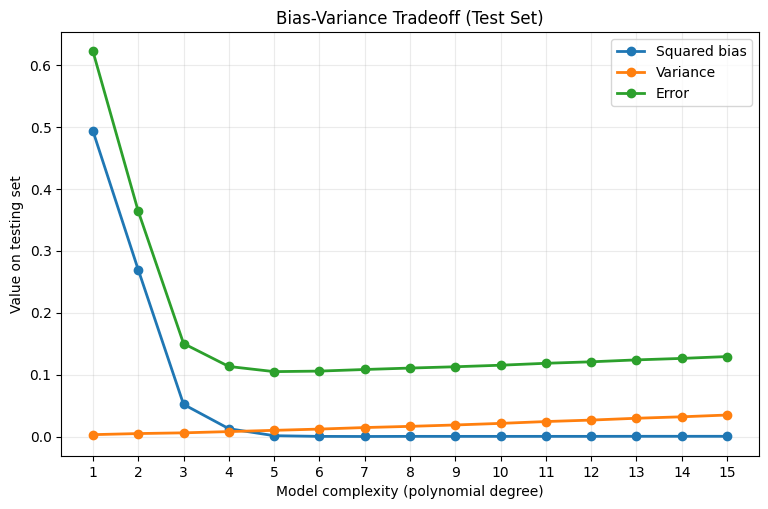

In [11]:
plt.figure(figsize=(9, 5.5))
plt.plot(degree_grid, bias2, marker='o', linewidth=2, label='Squared bias')
plt.plot(degree_grid, variance, marker='o', linewidth=2, label='Variance')
plt.plot(degree_grid, error, marker='o', linewidth=2, label='Error')
plt.xlabel('Model complexity (polynomial degree)')
plt.ylabel('Value on testing set')
plt.title('Bias-Variance Tradeoff (Test Set)')
plt.xticks(degree_grid)
plt.grid(alpha=0.25)
plt.legend()
plt.show()

In [12]:
best_idx = int(np.argmin(error))
best_degree = int(degree_grid[best_idx])

print(f'Best model: g{best_degree}')
print(f'Bias^2 for best model: {bias2[best_idx]:.6f}')
print(f'Variance for best model: {variance[best_idx]:.6f}')
print(f'Test error for best model: {error[best_idx]:.6f}')

Best model: g5
Bias^2 for best model: 0.001523
Variance for best model: 0.010172
Test error for best model: 0.104976


**Part 3b — Best Model Identification**

The model with the smallest test error is **g5** (degree-5 polynomial).

| Metric | Value |
|---|---|
| Squared bias | 0.001523 |
| Variance | 0.010172 |
| Test error | 0.104976 |

At degree 5 the estimator has effectively captured the shape of $f(x) = x + \sin(1.5x)$, driving squared bias to near zero while variance remains modest because each training set of 50 points sufficiently constrains a 6-parameter model. Beyond degree 5 the bias stays near zero but variance continues rising, causing total error to increase — the classic overfitting regime.

As a sanity check, the irreducible noise is $\sigma^2 = 0.3^2 = 0.09$, so the decomposition for g5 is:

$$\underbrace{0.001523}_{\text{bias}^2} + \underbrace{0.010172}_{\text{variance}} + \underbrace{0.09}_{\text{noise}} \approx 0.1017 \approx 0.105 = \text{test error} \checkmark$$